Processing videos:

 100 mW | R = 38.72 ± 6.86 µm
 200 mW | R = 34.02 ± 6.78 µm

Linear fit results:
slope      = 1.971e-06 µm⁻²/mW
intercept  = 4.699e-04
R²         = 1.0000
std error  = 0.000e+00

Relative apparent bending modulus ∝ 5.075e+05


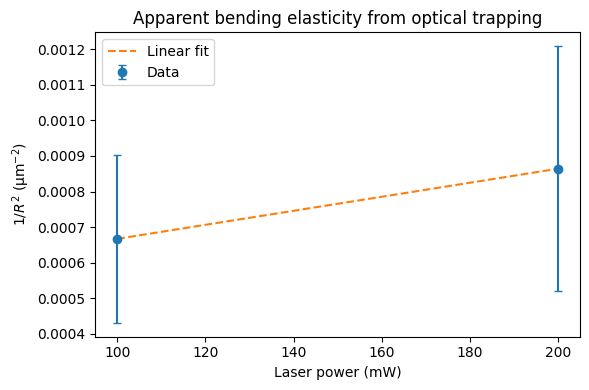

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ======================================================
# USER PARAMETERS
# ======================================================
pixel_to_micron = 0.11      # µm / pixel (from microscope calibration)
min_edge_points = 500       # minimum edge pixels to accept a frame

# Explicit video list: (path, laser power in mW)
videos = [
    ("/content/myelin 1-10102025144351-0000.avi", 100),
    ("/content/Media1.mp4", 200)
]

# ======================================================
# HELPER FUNCTIONS
# ======================================================
def extract_radii(video_path):
    """
    Extract curvature radii (in pixels) from all valid frames of a video.
    """
    cap = cv2.VideoCapture(video_path)
    radii = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Edge detection
        edges = cv2.Canny(gray, 50, 150)

        points = np.column_stack(np.where(edges > 0))
        if len(points) < min_edge_points:
            continue

        (_, _), radius = cv2.minEnclosingCircle(points)
        radii.append(radius)

    cap.release()
    return np.array(radii)


# ======================================================
# MAIN ANALYSIS
# ======================================================
powers = []
R_inv2 = []
R_err = []

print("Processing videos:\n")

for video_path, P in videos:
    radii_px = extract_radii(video_path)

    if len(radii_px) == 0:
        print(f"{P} mW | No valid frames")
        continue

    radii_um = radii_px * pixel_to_micron

    # Robust statistics
    R_med = np.median(radii_um)
    R_std = np.std(radii_um)

    powers.append(P)
    R_inv2.append(1.0 / R_med**2)
    R_err.append(2 * R_std / R_med**3)  # propagated error for 1/R^2

    print(f"{P:4.0f} mW | R = {R_med:.2f} ± {R_std:.2f} µm")

powers = np.array(powers)
R_inv2 = np.array(R_inv2)
R_err = np.array(R_err)

# ======================================================
# LINEAR FIT: 1/R^2 = (α/K) P
# ======================================================
slope, intercept, r, p, stderr = linregress(powers, R_inv2)

print("\nLinear fit results:")
print(f"slope      = {slope:.3e} µm⁻²/mW")
print(f"intercept  = {intercept:.3e}")
print(f"R²         = {r**2:.4f}")
print(f"std error  = {stderr:.3e}")

# Apparent modulus (relative, trap calibration unknown)
K_app_relative = 1 / slope
print(f"\nRelative apparent bending modulus ∝ {K_app_relative:.3e}")

# ======================================================
# PLOT
# ======================================================
plt.figure(figsize=(6, 4))

plt.errorbar(
    powers,
    R_inv2,
    yerr=R_err,
    fmt='o',
    capsize=3,
    label="Data"
)

P_fit = np.linspace(min(powers), max(powers), 200)
plt.plot(P_fit, slope * P_fit + intercept, '--', label="Linear fit")

plt.xlabel("Laser power (mW)")
plt.ylabel(r"$1/R^2$ (µm$^{-2}$)")
plt.title("Apparent bending elasticity from optical trapping")
plt.legend()
plt.tight_layout()
plt.show()


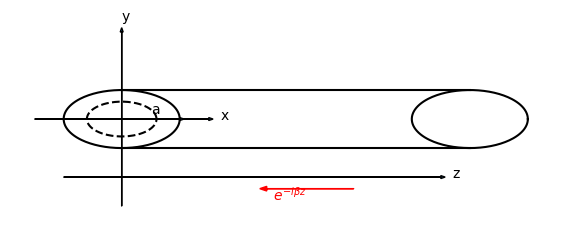

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,3))

# Cylinder edges
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), 0.5*np.sin(theta), 'k')
ax.plot(6 + np.cos(theta), 0.5*np.sin(theta), 'k')
ax.plot([0,6], [0.5,0.5], 'k')
ax.plot([0,6], [-0.5,-0.5], 'k')

# Dashed back face
ax.plot(0.6*np.cos(theta), 0.3*np.sin(theta), 'k--')

# Axes
ax.arrow(-1.5,0,3,0, head_width=0.05)
ax.text(1.7,0,'x')

ax.arrow(0,-1.5,0,3, head_width=0.05)
ax.text(0,1.7,'y')

ax.arrow(-1,-1,6.5,0, head_width=0.05)
ax.text(5.7,-1,'z')

# Radius a
ax.arrow(0,0,1,0, head_width=0.05)
ax.text(0.5,0.1,'a')

# Propagation arrow
ax.arrow(4,-1.2,-1.5,0, head_width=0.08, color='red')
ax.text(2.6,-1.4,r'$e^{-i\beta z}$', color='red')

ax.set_aspect('equal')
ax.axis('off')
plt.show()


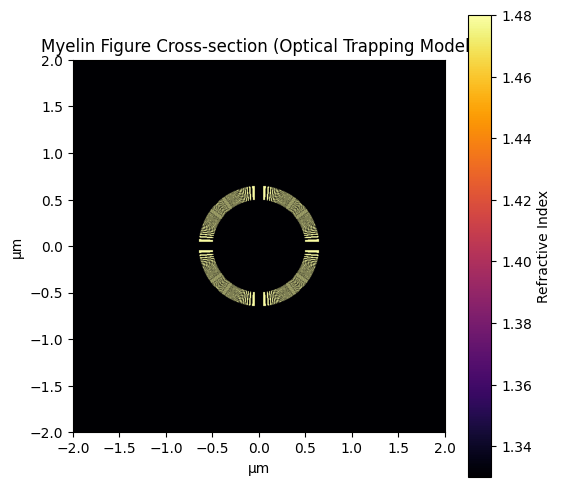

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r0 = 0.5e-6          # inner radius (m)
d = 5e-9             # bilayer spacing (m)
N = 30               # number of bilayers
resolution = 800     # grid resolution
L = 2e-6             # domain size

# Refractive indices
n_water = 1.33
n_lipid = 1.48

# Grid
x = np.linspace(-L, L, resolution)
y = np.linspace(-L, L, resolution)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Refractive index map
n = np.ones_like(R) * n_water

for i in range(N):
    r_inner = r0 + i * d
    r_outer = r_inner + d / 2
    mask = (R >= r_inner) & (R <= r_outer)
    n[mask] = n_lipid

# Plot
plt.figure(figsize=(6,6))
plt.imshow(n, extent=[-L*1e6, L*1e6, -L*1e6, L*1e6], cmap='inferno')
plt.colorbar(label='Refractive Index')
plt.xlabel('µm')
plt.ylabel('µm')
plt.title('Myelin Figure Cross-section (Optical Trapping Model)')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_bilayer(ax, x0, y0, length=4, spacing=0.4, n=8, angle=0):
    """
    Draws a bilayer cartoon with heads and tails
    """
    theta = np.deg2rad(angle)
    dx = np.cos(theta)
    dy = np.sin(theta)

    for i in range(n):
        x = x0 + i * spacing * dx
        y = y0 + i * spacing * dy

        # Top leaflet
        ax.plot([x, x], [y, y+0.5], color='black', lw=1)
        ax.plot(x, y+0.5, 'o', ms=4, mfc='white', mec='black')

        # Bottom leaflet
        ax.plot([x, x], [y, y-0.5], color='black', lw=1)
        ax.plot(x, y-0.5, 'o', ms=4, mfc='white', mec='black')


In [ ]:
def draw_water(ax, x_start, x_end, y=0, spacing=0.35):
    xs = np.arange(x_start, x_end, spacing)
    ax.plot(xs, np.ones_like(xs)*y, 'o', ms=3, color='black')


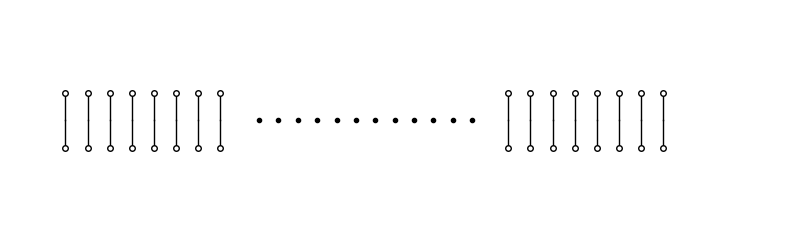

In [ ]:
fig, ax = plt.subplots(figsize=(10,3))

# Left bilayer
draw_bilayer(ax, x0=0, y0=0)

# Water layer
draw_water(ax, 3.5, 7.5)

# Right bilayer
draw_bilayer(ax, x0=8, y0=0)

# Formatting
ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1, 13)
ax.set_ylim(-2, 2)

plt.show()


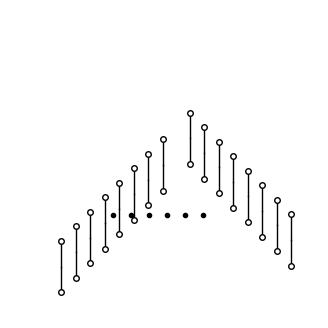

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))

draw_bilayer(ax, x0=0, y0=0, angle=45)
draw_bilayer(ax, x0=2.5, y0=2.5, angle=-45)

draw_water(ax, 1, 3, y=1)

ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

powers = np.array([1000, 900, 800, 700, 600, 500])  # mW
R = np.array([38.72, 34.02, 29.32, 24.62, 19.92, 15.22])  # µm

inv_R2 = 1 / R**2


In [ ]:
slope, intercept = np.polyfit(powers, inv_R2, 1)


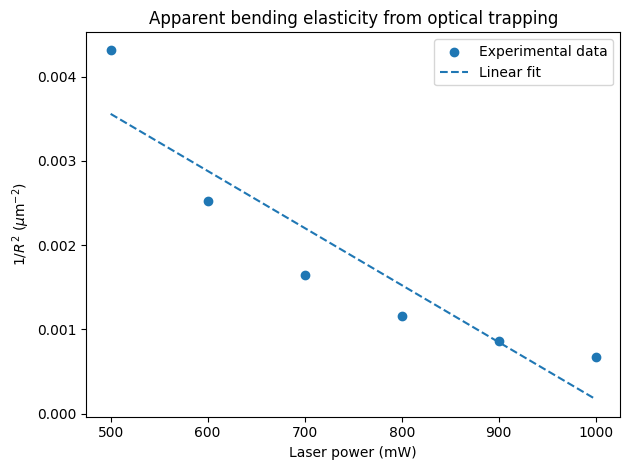

In [ ]:
P_fit = np.linspace(min(powers), max(powers), 200)

plt.scatter(powers, inv_R2, label="Experimental data")
plt.plot(P_fit, slope * P_fit + intercept, '--', label="Linear fit")

plt.xlabel("Laser power (mW)")
plt.ylabel(r"$1/R^2$ ($\mu$m$^{-2}$)")
plt.title("Apparent bending elasticity from optical trapping")

plt.legend()
plt.tight_layout()
plt.show()


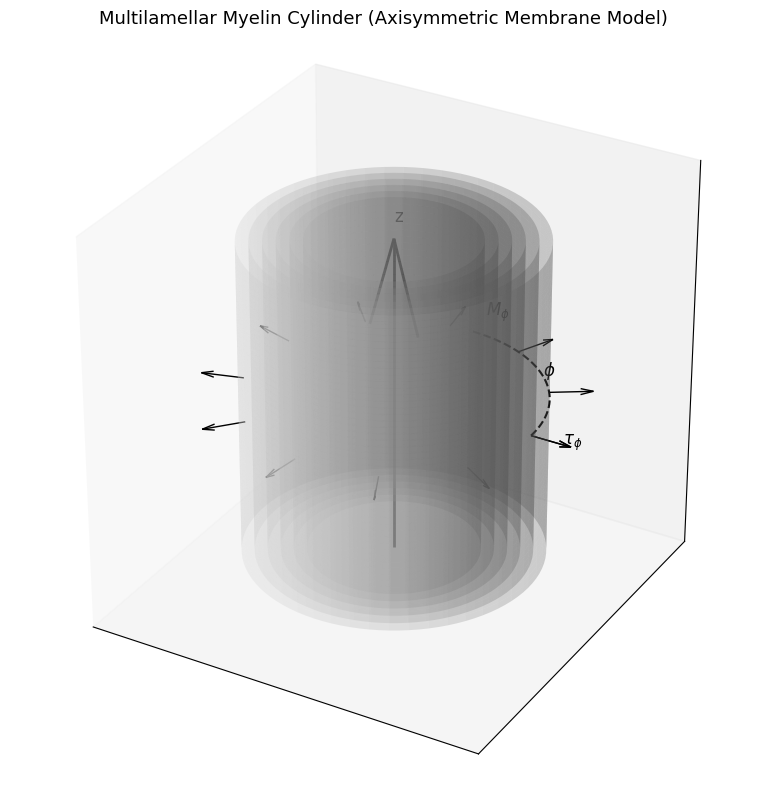

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Parameters
# -----------------------------
N_layers = 6          # number of bilayers
R0 = 1.0              # inner radius
dR = 0.15             # interlamellar spacing
L = 4.0               # cylinder length
phi = np.linspace(0, 2*np.pi, 100)
z = np.linspace(-L/2, L/2, 50)
Phi, Z = np.meshgrid(phi, z)

# -----------------------------
# Create figure
# -----------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# -----------------------------
# Draw multilamellar cylinders
# -----------------------------
for i in range(N_layers):
    R = R0 + i * dR
    X = R * np.cos(Phi)
    Y = R * np.sin(Phi)
    ax.plot_surface(
        X, Y, Z,
        color='lightgray',
        alpha=0.25,
        linewidth=0
    )

# -----------------------------
# Director field (normal vectors)
# -----------------------------
phi_dir = np.linspace(0, 2*np.pi, 12)
z_dir = np.zeros_like(phi_dir)
R_dir = R0 + (N_layers - 1) * dR

nx = np.cos(phi_dir)
ny = np.sin(phi_dir)
nz = np.zeros_like(nx)

ax.quiver(
    R_dir*np.cos(phi_dir),
    R_dir*np.sin(phi_dir),
    z_dir,
    nx, ny, nz,
    length=0.5,
    color='k',
    linewidth=1
)

# -----------------------------
# Axes and symmetry indication
# -----------------------------
ax.quiver(0, 0, -L/2, 0, 0, L, color='k', linewidth=2)
ax.text(0, 0, L/2 + 0.2, 'z', fontsize=12)

# Azimuthal angle φ arrow
theta = np.linspace(0, np.pi/2, 50)
ax.plot(
    R_dir*np.cos(theta),
    R_dir*np.sin(theta),
    np.zeros_like(theta),
    'k--'
)
ax.text(R_dir/np.sqrt(2), R_dir/np.sqrt(2), 0, r'$\phi$', fontsize=12)

# -----------------------------
# Stress annotations
# -----------------------------
ax.text(R_dir + 0.4, 0, 0, r'$\tau_\phi$', fontsize=12)
ax.text(0, R_dir + 0.4, 0, r'$M_\phi$', fontsize=12)

# -----------------------------
# Formatting
# -----------------------------
ax.set_box_aspect([1, 1, 1])
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_zlim(-2.5, 2.5)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_title("Multilamellar Myelin Cylinder (Axisymmetric Membrane Model)", fontsize=13)

plt.tight_layout()
plt.show()


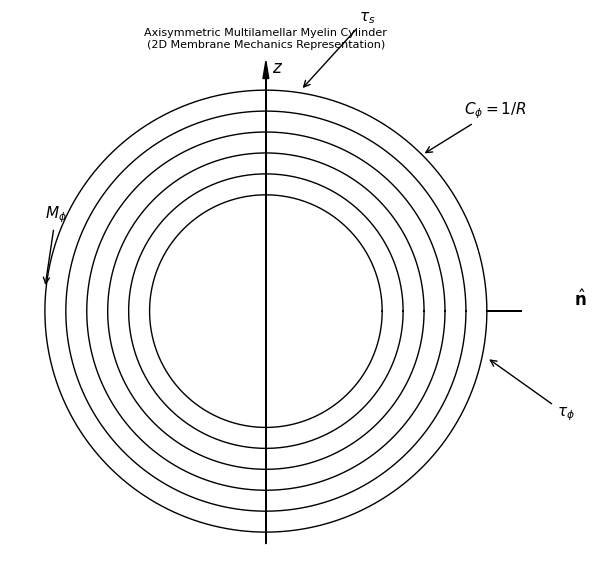

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N_layers = 6
R0 = 1.0
dR = 0.18

theta = np.linspace(0, 2*np.pi, 400)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# -----------------------------
# Draw multilamellar cross-section
# -----------------------------
for i in range(N_layers):
    R = R0 + i * dR
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    ax.plot(x, y, 'k', linewidth=1)

# -----------------------------
# Axis of symmetry (z)
# -----------------------------
ax.arrow(0, -2.0, 0, 4.0,
         head_width=0.05, head_length=0.15,
         fc='k', ec='k', linewidth=1)
ax.text(0.05, 2.05, r'$z$', fontsize=12)

# -----------------------------
# Normal vector n̂
# -----------------------------
R_n = R0 + (N_layers - 1) * dR
ax.arrow(R_n, 0, 0.6, 0,
         head_width=0.06, head_length=0.12,
         fc='k', ec='k')
ax.text(R_n + 0.75, 0.05, r'$\hat{\mathbf{n}}$', fontsize=12)

# -----------------------------
# Curvature annotation
# -----------------------------
ax.annotate(
    r'$C_\phi = 1/R$',
    xy=(R_n/np.sqrt(2), R_n/np.sqrt(2)),
    xytext=(1.7, 1.7),
    arrowprops=dict(arrowstyle='->', linewidth=1),
    fontsize=11
)

# -----------------------------
# Surface stresses
# -----------------------------
ax.annotate(
    r'$\tau_\phi$',
    xy=(R_n, -0.4),
    xytext=(R_n + 0.6, -0.9),
    arrowprops=dict(arrowstyle='->', linewidth=1),
    fontsize=11
)

ax.annotate(
    r'$\tau_s$',
    xy=(0.3, R_n),
    xytext=(0.8, R_n + 0.6),
    arrowprops=dict(arrowstyle='->', linewidth=1),
    fontsize=11
)

# -----------------------------
# Bending moment
# -----------------------------
ax.annotate(
    r'$M_\phi$',
    xy=(-R_n, 0.2),
    xytext=(-1.9, 0.8),
    arrowprops=dict(arrowstyle='->', linewidth=1),
    fontsize=11
)

# -----------------------------
# Formatting (PRL style)
# -----------------------------
ax.set_aspect('equal')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.axis('off')

ax.set_title(
    'Axisymmetric Multilamellar Myelin Cylinder\n(2D Membrane Mechanics Representation)',
    fontsize=8
)

plt.tight_layout()
plt.show()


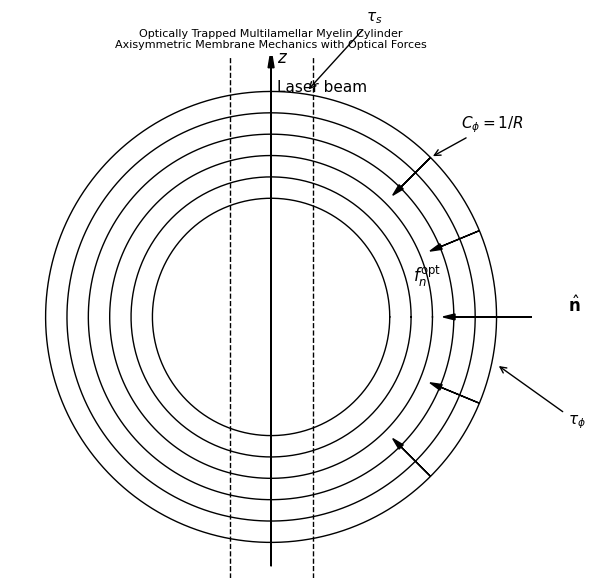

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N_layers = 6
R0 = 1.0
dR = 0.18
theta = np.linspace(0, 2*np.pi, 400)

R_outer = R0 + (N_layers - 1) * dR

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# -----------------------------
# Multilamellar cross-section
# -----------------------------
for i in range(N_layers):
    R = R0 + i * dR
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    ax.plot(x, y, 'k', linewidth=1)

# -----------------------------
# Optical trap (Gaussian beam)
# -----------------------------
z = np.linspace(-2.2, 2.2, 200)
w0 = 0.35  # beam waist

ax.plot(+w0*np.ones_like(z), z, 'k--', linewidth=1)
ax.plot(-w0*np.ones_like(z), z, 'k--', linewidth=1)
ax.text(0.05, 1.9, r'Laser beam', fontsize=11)

# -----------------------------
# Optical gradient force arrows
# -----------------------------
for angle in np.linspace(-np.pi/4, np.pi/4, 5):
    x0 = R_outer * np.cos(angle)
    y0 = R_outer * np.sin(angle)
    ax.arrow(
        x0, y0,
        -0.35*np.cos(angle), -0.35*np.sin(angle),
        head_width=0.05,
        head_length=0.1,
        fc='k', ec='k'
    )

ax.text(1.2, 0.3, r'$f_n^{\mathrm{opt}}$', fontsize=12)

# -----------------------------
# Axis of symmetry (z)
# -----------------------------
ax.arrow(0, -2.1, 0, 4.2,
         head_width=0.05,
         head_length=0.15,
         fc='k', ec='k')
ax.text(0.05, 2.15, r'$z$', fontsize=12)

# -----------------------------
# Normal vector
# -----------------------------
ax.arrow(R_outer, 0, 0.5, 0,
         head_width=0.05,
         head_length=0.1,
         fc='k', ec='k')
ax.text(R_outer + 0.6, 0.05, r'$\hat{\mathbf{n}}$', fontsize=12)

# -----------------------------
# Curvature
# -----------------------------
ax.annotate(
    r'$C_\phi = 1/R$',
    xy=(R_outer/np.sqrt(2), R_outer/np.sqrt(2)),
    xytext=(1.6, 1.6),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

# -----------------------------
# Surface stresses
# -----------------------------
ax.annotate(
    r'$\tau_\phi$',
    xy=(R_outer, -0.4),
    xytext=(R_outer + 0.6, -0.9),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

ax.annotate(
    r'$\tau_s$',
    xy=(0.3, R_outer),
    xytext=(0.8, R_outer + 0.6),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_aspect('equal')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.axis('off')

ax.set_title(
    'Optically Trapped Multilamellar Myelin Cylinder\n'
    'Axisymmetric Membrane Mechanics with Optical Forces',
    fontsize=8
)

plt.tight_layout()
plt.show()


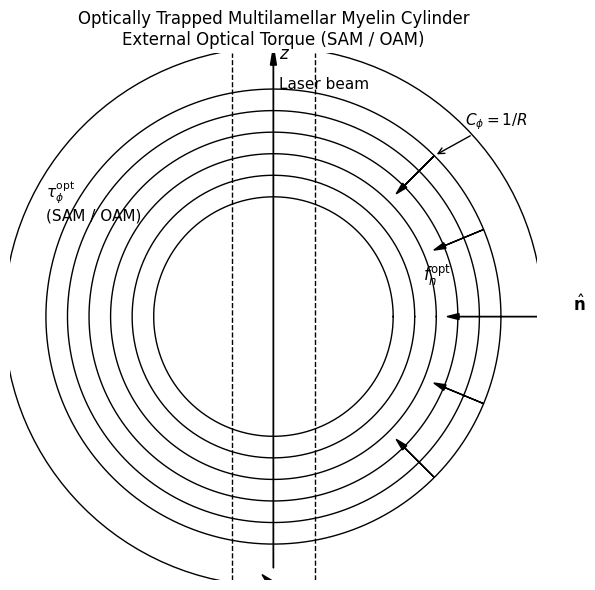

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
N_layers = 6
R0 = 1.0
dR = 0.18
theta = np.linspace(0, 2*np.pi, 400)

R_outer = R0 + (N_layers - 1) * dR

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# -----------------------------
# Multilamellar cross-section
# -----------------------------
for i in range(N_layers):
    R = R0 + i * dR
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    ax.plot(x, y, 'k', linewidth=1)

# -----------------------------
# Optical beam (waist)
# -----------------------------
z = np.linspace(-2.2, 2.2, 200)
w0 = 0.35

ax.plot(+w0*np.ones_like(z), z, 'k--', linewidth=1)
ax.plot(-w0*np.ones_like(z), z, 'k--', linewidth=1)
ax.text(0.05, 1.9, 'Laser beam', fontsize=11)

# -----------------------------
# Optical gradient force
# -----------------------------
for angle in np.linspace(-np.pi/4, np.pi/4, 5):
    x0 = R_outer * np.cos(angle)
    y0 = R_outer * np.sin(angle)
    ax.arrow(
        x0, y0,
        -0.35*np.cos(angle), -0.35*np.sin(angle),
        head_width=0.05,
        head_length=0.1,
        fc='k', ec='k'
    )

ax.text(1.25, 0.3, r'$f_n^{\mathrm{opt}}$', fontsize=12)

# -----------------------------
# Optical torque (SAM / OAM)
# -----------------------------
phi_torque = np.linspace(0, 1.5*np.pi, 100)
r_torque = R_outer + 0.35

x_t = r_torque * np.cos(phi_torque)
y_t = r_torque * np.sin(phi_torque)
ax.plot(x_t, y_t, 'k', linewidth=1)

ax.arrow(
    x_t[-1], y_t[-1],
    -0.01, 0.01,
    head_width=0.06,
    head_length=0.12,
    fc='k', ec='k'
)

ax.text(-1.9, 0.8,
        r'$\tau_\phi^{\mathrm{opt}}$' '\n(SAM / OAM)',
        fontsize=11)

# -----------------------------
# Axis of symmetry
# -----------------------------
ax.arrow(0, -2.1, 0, 4.2,
         head_width=0.05,
         head_length=0.15,
         fc='k', ec='k')
ax.text(0.05, 2.15, r'$z$', fontsize=12)

# -----------------------------
# Normal vector
# -----------------------------
ax.arrow(R_outer, 0, 0.5, 0,
         head_width=0.05,
         head_length=0.1,
         fc='k', ec='k')
ax.text(R_outer + 0.6, 0.05, r'$\hat{\mathbf{n}}$', fontsize=12)

# -----------------------------
# Curvature
# -----------------------------
ax.annotate(
    r'$C_\phi = 1/R$',
    xy=(R_outer/np.sqrt(2), R_outer/np.sqrt(2)),
    xytext=(1.6, 1.6),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_aspect('equal')
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.axis('off')

ax.set_title(
    'Optically Trapped Multilamellar Myelin Cylinder\n'
    'External Optical Torque (SAM / OAM)',
    fontsize=12
)

plt.tight_layout()
plt.show()
